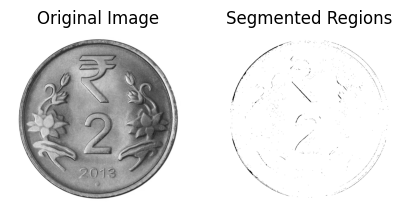

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
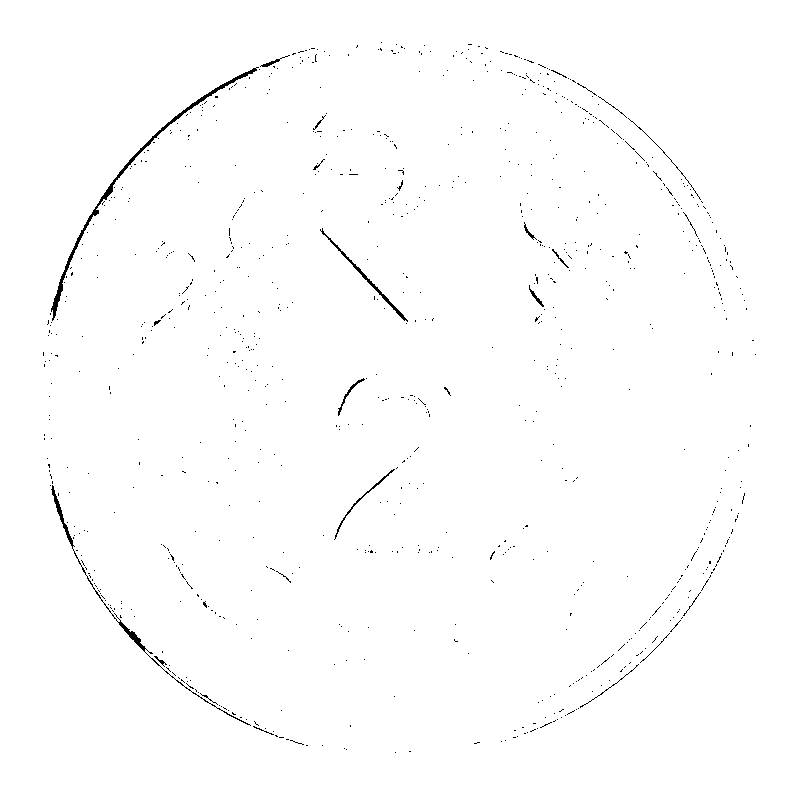

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold):
    segmented_image = np.zeros_like(image, dtype=np.uint8)
    segmented_image[seed[1], seed[0]] = 255

    pixel_list = [seed]
    while pixel_list:
        x, y = pixel_list.pop(0)

        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < image.shape[1] and 0 <= ny < image.shape[0] and segmented_image[ny, nx] == 0:
                if abs(int(image[ny, nx]) - int(image[y, x])) < threshold:
                    segmented_image[ny, nx] = 255
                    pixel_list.append((nx, ny))

    return segmented_image

def detect_coins(image_path, seed, threshold):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found. Check the path.")

    segmented_image = region_growing(image, seed, threshold)

    plt.figure(figsize=(5, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image, cmap="gray")
    plt.title("Segmented Regions")
    plt.axis("off")

    plt.show()

    return segmented_image

detect_coins(r"/content/coin.jpg", seed=(50, 50), threshold=30)

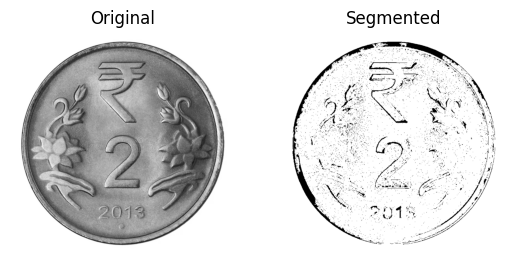

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold):
    segmented = np.zeros_like(image, dtype=np.uint8)
    segmented[seed[1], seed[0]] = 255
    queue = [seed]

    while queue:
        x, y = queue.pop(0)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < image.shape[1] and 0 <= ny < image.shape[0] and segmented[ny, nx] == 0:
                if abs(int(image[ny, nx]) - int(image[y, x])) < threshold:
                    segmented[ny, nx] = 255
                    queue.append((nx, ny))
    return segmented

def detect_coins(image_path, seed=(50, 50), threshold=16):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found. Check the path.")

    segmented = region_growing(image, seed, threshold)

    plt.subplot(1, 2, 1), plt.imshow(image, cmap="gray"), plt.title("Original"), plt.axis("off")
    plt.subplot(1, 2, 2), plt.imshow(segmented, cmap="gray"), plt.title("Segmented"), plt.axis("off")
    plt.show()

detect_coins("/content/coin.jpg")


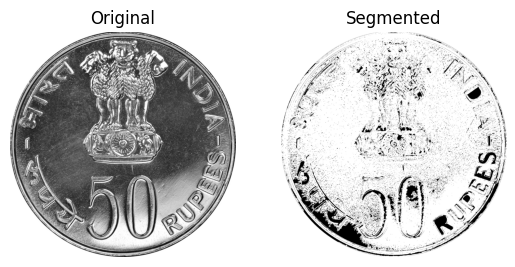

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold):
    segmented = np.zeros_like(image, dtype=np.uint8)
    segmented[seed[1], seed[0]] = 255
    queue = [seed]

    while queue:
        x, y = queue.pop(0)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < image.shape[1] and 0 <= ny < image.shape[0] and segmented[ny, nx] == 0:
                if abs(int(image[ny, nx]) - int(image[y, x])) < threshold:
                    segmented[ny, nx] = 255
                    queue.append((nx, ny))
    return segmented

def detect_coins(image_path, seed=(50, 50), threshold=30):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found. Check the path.")

    segmented = region_growing(image, seed, threshold)

    plt.subplot(1, 2, 1), plt.imshow(image, cmap="gray"), plt.title("Original"), plt.axis("off")
    plt.subplot(1, 2, 2), plt.imshow(segmented, cmap="gray"), plt.title("Segmented"), plt.axis("off")
    plt.show()

detect_coins("/content/c.jpg")


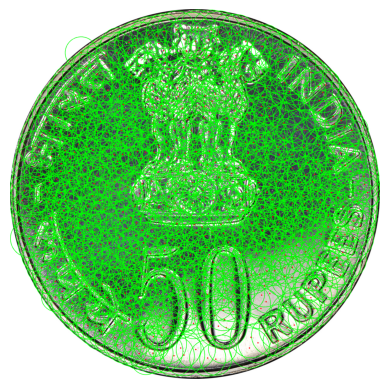

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image from file (example path)
image_path = '/content/c.jpg'  # Change this to the correct path
coins = cv2.imread(image_path, cv2.IMREAD_COLOR)

# Check if the image is loaded properly
if coins is None:
    raise FileNotFoundError(f"Image not found or could not be loaded: {image_path}")

# Function call for Hough Circle Detection
min_r = 75  # Minimum radius
max_r = 115  # Maximum radius

def hough_circle_detection(coins, min_r, max_r):
    gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)  # Convert image to grayscale
    blurred = cv2.medianBlur(gray, 5)  # Apply median blur to reduce noise

    # Call HoughCircles
    circles = cv2.HoughCircles(
        blurred,  # Source image (blurred and grayscaled)
        cv2.HOUGH_GRADIENT,  # Method for circle detection
        1,  # Inverse ratio of accumulator resolution to image resolution
        40,  # Minimum distance between detected circles' centers
        param1=50,  # Gradient value for edge detection
        param2=30,  # Accumulator threshold for circle detection
        minRadius=min_r,  # Minimum circle radius
        maxRadius=max_r  # Maximum circle radius
    )

    # If circles are detected
    if circles is not None:
        circles = np.uint16(np.around(circles))  # Round coordinates to integers

        # Draw the circles on the original image (create a copy to avoid modifying original)
        output = coins.copy()
        for i in circles[0, :]:
            # Draw the outer circle
            cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Draw the center of the circle
            cv2.circle(output, (i[0], i[1]), 2, (0, 0, 255), 3)

        return output
    else:
        print("No circles detected.")
        return coins  # Return the original image if no circles are detected

# Call the function
result_image = hough_circle_detection(coins, min_r, max_r)

# Convert the result image from BGR to RGB for displaying with matplotlib
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(result_image_rgb)
plt.axis('off')  # Hide axes
plt.show()


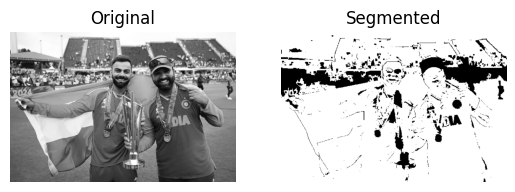

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold):
    segmented = np.zeros_like(image, dtype=np.uint8)
    segmented[seed[1], seed[0]] = 255
    queue = [seed]

    while queue:
        x, y = queue.pop(0)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < image.shape[1] and 0 <= ny < image.shape[0] and segmented[ny, nx] == 0:
                if abs(int(image[ny, nx]) - int(image[y, x])) < threshold:
                    segmented[ny, nx] = 255
                    queue.append((nx, ny))
    return segmented

def detect_coins(image_path, seed=(50, 50), threshold=17):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found. Check the path.")

    segmented = region_growing(image, seed, threshold)

    plt.subplot(1, 2, 1), plt.imshow(image, cmap="gray"), plt.title("Original"), plt.axis("off")
    plt.subplot(1, 2, 2), plt.imshow(segmented, cmap="gray"), plt.title("Segmented"), plt.axis("off")
    plt.show()

detect_coins("/content/ro-ko.jpg")


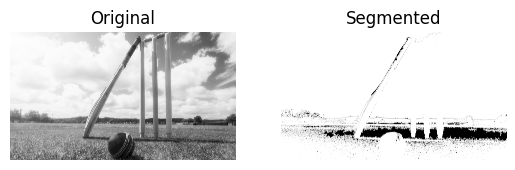

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold):
    segmented = np.zeros_like(image, dtype=np.uint8)
    segmented[seed[1], seed[0]] = 255
    queue = [seed]

    while queue:
        x, y = queue.pop(0)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < image.shape[1] and 0 <= ny < image.shape[0] and segmented[ny, nx] == 0:
                if abs(int(image[ny, nx]) - int(image[y, x])) < threshold:
                    segmented[ny, nx] = 255
                    queue.append((nx, ny))
    return segmented

def detect_coins(image_path, seed=(50, 50), threshold=9):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found. Check the path.")

    segmented = region_growing(image, seed, threshold)

    plt.subplot(1, 2, 1), plt.imshow(image, cmap="gray"), plt.title("Original"), plt.axis("off")
    plt.subplot(1, 2, 2), plt.imshow(segmented, cmap="gray"), plt.title("Segmented"), plt.axis("off")
    plt.show()

detect_coins("/content/cric.jpg")
